
# Pretrained YOLOv8 Fine-Tuning on KITTI Dataset
To complete our YOLO exercises, this notebook fine-tunes a **pretrained YOLOv8n** model on KITTI for three classes: `Car`, `Pedestrian`, and `Cyclist`. After training a Mini-YOLO from scratch in the last exercises, this is the more practical approach that you would follow for realizing your own applications. 

**Steps in this exercise:**
- Download KITTI images and labels 
- Convert KITTI annotations to YOLO format for our three classes
- Build a minimal YOLO dataset structure (`images/train|val`, `labels/train|val`)
- Fine-tune the pretrained `yolov8n.pt` and evaluate


In [10]:
# Import necessary libraries
import os, zipfile, urllib.request, shutil
from glob import glob
from pathlib import Path

import cv2
import numpy as np
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
%matplotlib inline

# Optional: set a fixed seed for reproducibility of splits
import random
random.seed(42)
np.random.seed(42)


## 1) Download KITTI dataset

As before, we download the KITTI dataset:

In [11]:
from pathlib import Path
import urllib.request
import zipfile

DATA_ROOT = Path("data")
DATA_ROOT.mkdir(exist_ok=True)

# Where KITTI training data should live AFTER extraction
KITTI_TRAIN_DIR = DATA_ROOT / "training"

IMAGES_DIR = KITTI_TRAIN_DIR / "image_2"
LABELS_DIR = KITTI_TRAIN_DIR / "label_2"

IMG_ZIP = DATA_ROOT / "kitti_images.zip"
LBL_ZIP = DATA_ROOT / "kitti_labels.zip"


In [12]:
images_ok = IMAGES_DIR.exists() and len(list(IMAGES_DIR.glob("*.png"))) > 0
labels_ok = LABELS_DIR.exists() and len(list(LABELS_DIR.glob("*.txt"))) > 0

if images_ok and labels_ok:
    print("KITTI images and labels already present — skipping download.")


KITTI images and labels already present — skipping download.


In [13]:
if not images_ok:
    if not IMG_ZIP.exists():
        print("Downloading KITTI images ...")
        urllib.request.urlretrieve(
            "https://s3.eu-central-1.amazonaws.com/avg-kitti/data_object_image_2.zip",
            IMG_ZIP.as_posix()
        )
        print("Images downloaded.")

    print("Extracting KITTI images ...")
    with zipfile.ZipFile(IMG_ZIP, "r") as zf:
        zf.extractall(DATA_ROOT)
    print("Images extracted.")

if not labels_ok:
    if not LBL_ZIP.exists():
        print("Downloading KITTI labels ...")
        urllib.request.urlretrieve(
            "https://s3.eu-central-1.amazonaws.com/avg-kitti/data_object_label_2.zip",
            LBL_ZIP.as_posix()
        )
        print("Labels downloaded.")

    print("Extracting KITTI labels ...")
    with zipfile.ZipFile(LBL_ZIP, "r") as zf:
        zf.extractall(DATA_ROOT)
    print("Labels extracted.")


In [14]:
assert IMAGES_DIR.exists(), f"Image directory not found: {IMAGES_DIR}"
assert LABELS_DIR.exists(), f"Label directory not found: {LABELS_DIR}"

n_imgs = len(list(IMAGES_DIR.glob("*.png")))
n_lbls = len(list(LABELS_DIR.glob("*.txt")))

print(f"KITTI images found: {n_imgs}")
print(f"KITTI labels found: {n_lbls}")

assert n_imgs > 0, "No KITTI images found after extraction!"
assert n_lbls > 0, "No KITTI labels found after extraction!"


KITTI images found: 7481
KITTI labels found: 7481


## 2) Convert KITTI labels to YOLO format and build dataset directories

As before, we have to convert our KITTI data to YOLO format:

In [15]:

# Selected classes and mapping
SELECTED_CLASSES = ["Car", "Pedestrian", "Cyclist"]
CLASS_TO_ID = {c:i for i,c in enumerate(SELECTED_CLASSES)}

# images_src = base_dir / "training" / "image_2"
# labels_src = base_dir / "training" / "label_2"
images_src = IMAGES_DIR
labels_src = LABELS_DIR

# Target YOLO dataset structure
yolo_root = Path("data/kitti_yolo")
imgs_train_dir = yolo_root / "images" / "train"
imgs_val_dir   = yolo_root / "images" / "val"
lbls_train_dir = yolo_root / "labels" / "train"
lbls_val_dir   = yolo_root / "labels" / "val"
for d in [imgs_train_dir, imgs_val_dir, lbls_train_dir, lbls_val_dir]:
    d.mkdir(parents=True, exist_ok=True)

# Choose subset sizes
TOTAL = 600   # total images used
TEST_SIZE = 0.17  # ~500 train / 100 val

all_imgs = sorted(images_src.glob("*.png"))[:TOTAL]
train_imgs, val_imgs = train_test_split(all_imgs, test_size=TEST_SIZE, random_state=42)


def convert_line_to_yolo(parts, img_w, img_h):
    # parts: split line of KITTI label file
    cls_name = parts[0]
    if cls_name not in CLASS_TO_ID:
        return None
    try:
        x1, y1, x2, y2 = map(float, parts[4:8])
    except:
        return None
    
    # Normalize to [0,1] relative to actual image size
    x_c = ((x1 + x2) / 2.0) / img_w
    y_c = ((y1 + y2) / 2.0) / img_h
    w   = (x2 - x1) / img_w
    h   = (y2 - y1) / img_h
    if w <= 0 or h <= 0:
        return None
    cls_id = CLASS_TO_ID[cls_name]
    return f"{cls_id} {x_c:.6f} {y_c:.6f} {w:.6f} {h:.6f}\n"

# Process splits
def process_split(img_list, imgs_out_dir, lbls_out_dir):
    converted = 0
    for img_path in img_list:
        stem = img_path.stem
        lbl_path = labels_src / f"{stem}.txt"
        # Read image to get actual size (KITTI widths may vary slightly)
        img = cv2.imread(img_path.as_posix())
        if img is None:
            continue
        h, w = img.shape[:2]

        yolo_lines = []
        if lbl_path.exists():
            with open(lbl_path, "r") as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) < 8:
                        continue
                    s = convert_line_to_yolo(parts, w, h)
                    if s:
                        yolo_lines.append(s)

        # Skip images without any selected-class boxes to keep training meaningful
        if len(yolo_lines) == 0:
            continue

        # Copy image
        shutil.copy2(img_path.as_posix(), (imgs_out_dir / img_path.name).as_posix())
        # Write label
        with open((lbls_out_dir / f"{stem}.txt").as_posix(), "w") as f:
            f.writelines(yolo_lines)
        converted += 1
    return converted

# Process train and val splits
n_train = process_split(train_imgs, imgs_train_dir, lbls_train_dir)
n_val   = process_split(val_imgs, imgs_val_dir, lbls_val_dir)

print(f"Built YOLO dataset!")
print(f"Train images with labels: {n_train}, Val images with labels: {n_val}")

Built YOLO dataset!
Train images with labels: 497, Val images with labels: 103


## 3) Create dataset YAML file for Ultralytics

Now we create the dataset YAML file required by Ultralytics YOLO implementations. We specify the paths to the train and val image directories as well as the class names.

In [16]:
# Write dataset YAML file
yaml_path = Path("data/kitti_yolo.yaml")
yaml_text = f"""
path: {yolo_root.resolve()}
train: images/train
val: images/val

nc: 3
names: {SELECTED_CLASSES}
"""
yaml_path.write_text(yaml_text)
print("Wrote dataset YAML to:", yaml_path.resolve())
print("\nPreview:\n", yaml_text)


Wrote dataset YAML to: C:\Users\muntzinger\Documents\Arbeit_HFT\9_Sonstiges\Udacity_Instructor\DLND\Code\cd1821-vision-CNNs\lesson-9-detection\demos\data\kitti_yolo.yaml

Preview:
 
path: C:\Users\muntzinger\Documents\Arbeit_HFT\9_Sonstiges\Udacity_Instructor\DLND\Code\cd1821-vision-CNNs\lesson-9-detection\demos\data\kitti_yolo
train: images/train
val: images/val

nc: 3
names: ['Car', 'Pedestrian', 'Cyclist']



## 4) Fine-tune pretrained YOLOv8n

Now it's time to fine-tune a pretrained YOLOv8 model on our KITTI dataset. We'll use the ultralytics package for this.

In [17]:
# Import YOLO and set device
from ultralytics import YOLO
import torch

device = 0 if torch.cuda.is_available() else "cpu"
print("Training device:", device)

model = YOLO("yolov8n.pt")  # pretrained on COCO

# use deterministic CUDA behaviour
torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True

results = model.train(
    data=yaml_path.as_posix(),
    epochs=20,
    imgsz=640,
    batch=8,
    device=device,
    workers=0,      
    verbose=True,
    name="yolov8n_kitti3_local"
)
results

Training device: cpu
New https://pypi.org/project/ultralytics/8.3.237 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.221  Python-3.12.5 torch-2.8.0+cpu CPU (13th Gen Intel Core i5-1335U)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data/kitti_yolo.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=yolov8n_kitti3_local2, 

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x000001CF2D68E8D0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([0.        , 0.001001  , 0.002002  , 0.003003  , 0.004004  ,
       0.00500501, 0.00600601, 0.00700701, 0.00800801, 0.00900901,
       0.01001001, 0.01101101, 0.01201201, 0.01301301, 0.01401401,
       0.01501502, 0.01601602, 0.01701702, 0.01801802, 0.01901902,
       0.02002002, 0.02102102, 0.02202202, 0.02302302, 0.02402402,
       0.02502503, 0.02602603, 0.02702703, 0.02802803, 0.02902903,
       0.03003003, 0.03103103, 0.03203203, 0.03303303, 0.03403403,
       0.03503504, 0.03603604, 0.03703704, 0.03803804, 0.03903904,
       0.04004004, 0.04104104, 0.04204204, 0.04304304, 0.04404404,
       0.04504505, 0.04604605, 0.04704705, 0.

## 5) Evaluate and run predictions

Finally, we evaluate the model: We run predictions on validation images and calculate final evaluation metrics.

In [18]:
# Evaluate the model on validation set
metrics = model.val(data=yaml_path.as_posix(), imgsz=640, batch=8, device=device)
print(metrics)

# Run predictions on validation images
pred_dir = Path("runs/predict_kitti3")
pred_dir.mkdir(parents=True, exist_ok=True)

results = model.predict(
    source=(yolo_root / "images" / "val").as_posix(),
    save=True,
    project=pred_dir.as_posix(),
    name="pred",
    imgsz=640,
    conf=0.25
)


Ultralytics 8.3.221  Python-3.12.5 torch-2.8.0+cpu CPU (13th Gen Intel Core i5-1335U)
Model summary (fused): 72 layers, 3,006,233 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access  (ping: 0.20.0 ms, read: 1270.4149.9 MB/s, size: 813.9 KB)
val: Scanning C:\Users\muntzinger\Documents\Arbeit_HFT\9_Sonstiges\Udacity_Instructor\DLND\Code\cd1821-vision-CNNs\lesson-9-detection\demos\data\kitti_yolo\labels\val.cache... 103 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 103/103 102.7Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 13/13 2.4it/s 5.4s0.4s
                   all        103        486      0.586      0.548      0.575      0.362
                   Car         91        390      0.792      0.769      0.845      0.572
            Pedestrian         28         81      0.682      0.531      0.555      0.284
               Cyclist         11         15      0.284      0.345      0.325      0.228
Speed: 0.

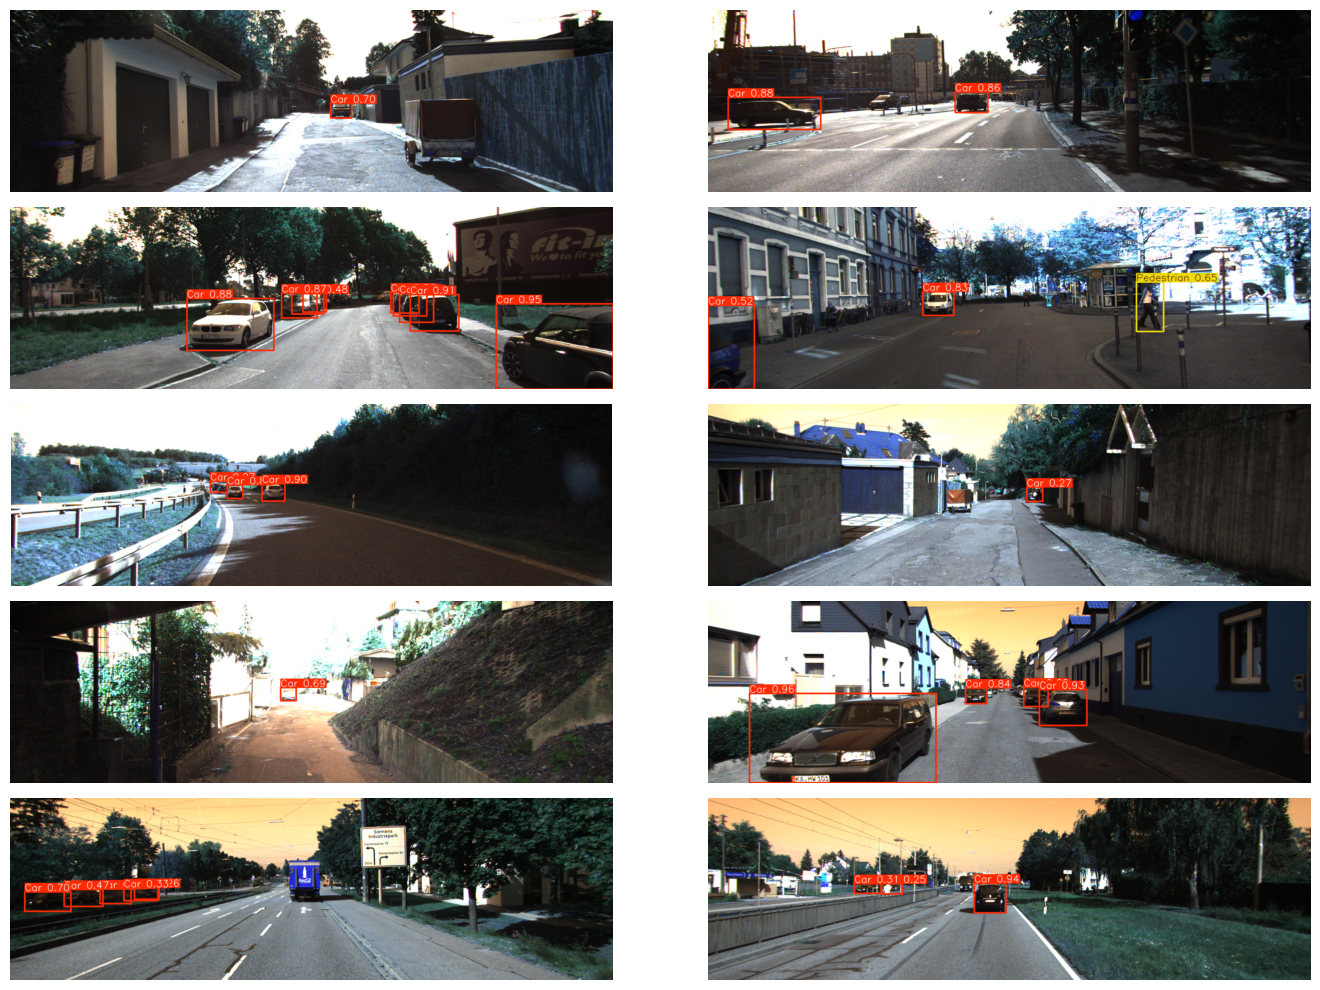

In [19]:
# Visualize some predictions in the notebook
rows, cols = 5, 2
plt.figure(figsize=(15, 10))
for i in range(min(rows * cols, len(results))):
    im = results[i].plot()
    plt.subplot(rows, cols, i + 1)
    plt.imshow(im)
    plt.axis("off")
plt.tight_layout()
plt.show()


In [20]:
# Evaluate the model to get final metrics
metrics = model.val(data=yaml_path.as_posix(), imgsz=640, batch=8, device=device)
print(metrics.results_dict)

Ultralytics 8.3.221  Python-3.12.5 torch-2.8.0+cpu CPU (13th Gen Intel Core i5-1335U)
val: Fast image access  (ping: 0.20.1 ms, read: 934.9257.3 MB/s, size: 828.3 KB)
val: Scanning C:\Users\muntzinger\Documents\Arbeit_HFT\9_Sonstiges\Udacity_Instructor\DLND\Code\cd1821-vision-CNNs\lesson-9-detection\demos\data\kitti_yolo\labels\val.cache... 103 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 103/103 102.8Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 13/13 2.4it/s 5.5s0.4s
                   all        103        486      0.586      0.548      0.575      0.362
                   Car         91        390      0.792      0.769      0.845      0.572
            Pedestrian         28         81      0.682      0.531      0.555      0.284
               Cyclist         11         15      0.284      0.345      0.325      0.228
Speed: 0.9ms preprocess, 37.8ms inference, 0.0ms loss, 0.6ms postprocess per image
Results

Now it's your turn! Why don't you get creative and build your own application with a pretrained YOLO detector based on this notebook? Maybe a simple grocery stock checker, a pet monitor or a lost-and-found detector? 🤩